# Density-Based Clustering

In this example, we will continue to examine *unsupervised* clustering techniques designed to uncover patterns in data when specific labels have not yet been provided for the target features.

**Learning Objectives**

1. Describe the concept of density-based clustering and how it differs from $k$-means clustering
2. Apply DBSCAN clustering using the `scikit-learn` toolkit
3. Apply OPTICS clustering using the `scikit-learn` toolkit 

**Import modules**

Begin by importing the modules to be used in this notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn.cluster import KMeans, DBSCAN, OPTICS, HDBSCAN
from sklearn.datasets import make_moons, make_blobs

In [3]:
# get a color list for plotting
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## Density-Based Clustering

In our $k$-means clustering example from the previous notebook, we implicitly assumed that each cluster should be circular in shape. This assumption is based on our definition of distance - the Euclidean distance. This distance effectively defines circular clusters. However, this assumption is not always appropriate for a given dataset. Consider, for example, the following artificial data set:

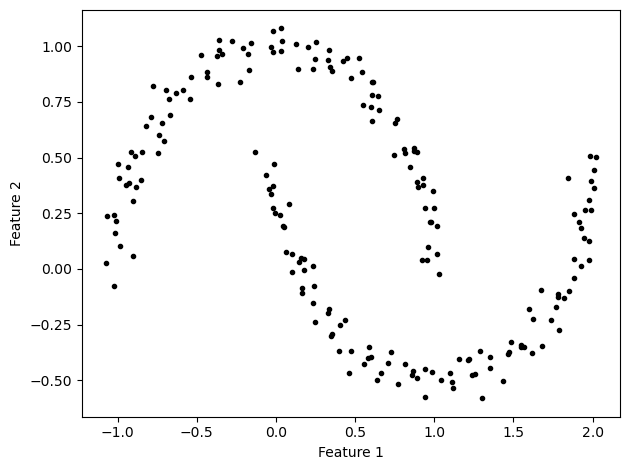

In [4]:
X_moon, y = make_moons(n_samples=200,
                  noise=0.05,
                  random_state=0)
plt.plot(X_moon[:, 0], X_moon[:, 1], 'k.')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

Clearly, there are two clusters in this set. Let's see how our $k$-means clustering algorithm performs on this set:

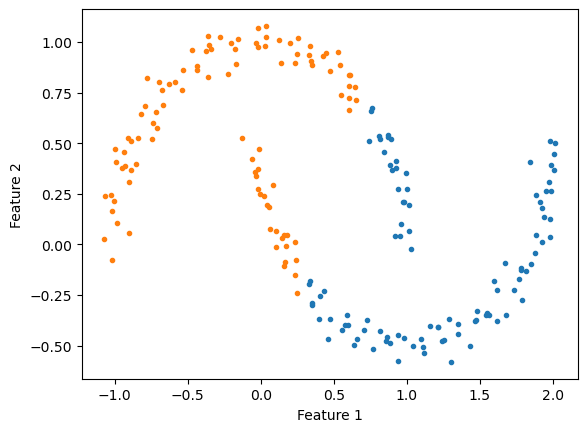

In [5]:
km_moon = KMeans(n_clusters=2, init='random', n_init=10, random_state=0)
classification_moon = km_moon.fit_predict(X_moon)
for k in range(2):
    plt.plot(X_moon[classification_moon==k,0],
             X_moon[classification_moon==k,1],'.', color=colors[k])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Clearly, this is not a desirable clustering - we're not getting the shape of the clusters quite right. For this example, we're going to need a new approach for clustering.

### DBSCAN

To improve clustering for this type of data, we need to remove the assumption that the clusters will be spherical. One option is to consider the *density* of points by counting the number of points within a given radius $\varepsilon$ of other points. If the number of points within this radius is greater than some prescribed minimum value $m$, then the region is considered dense. This is the foundation of the **Density-Based Spatial Clustering of Applications with Noise** (DBSCAN) algorithm.

In DBSCAN, we begin by assigning labels to each individual point according to the following table:

| Label | Description |
|-------|-------------|
| Core Point | At least $m$ points are within a distance $\varepsilon$ of the point |
| Border Point | The point is not a core point but it is within a distance $\varepsilon$ of a core point |
| Noise Point | The point is neither a core point nor a border point |

According to these labels, the clusters are then defined as follows:
1. Each individual core point is assigned its own cluster.
2. If a core point is within a distance $\varepsilon$ of another core point, those two clusters are merged.
3. Each border point is assigned to the cluster of its corresponding core point

Note that the noise points are not included in this approach. Let's see how DBSCAN performs on the test data:

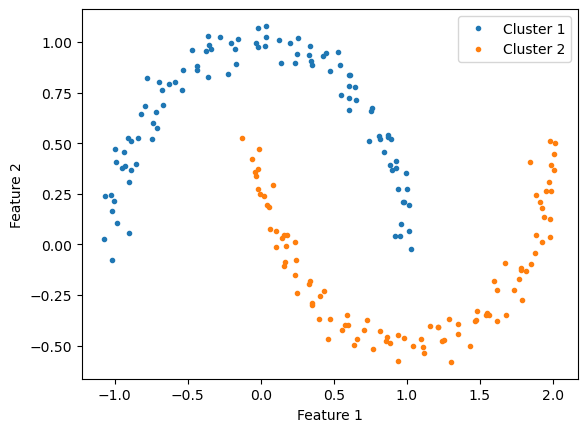

In [6]:
# implement the DBSCAN algorithm
db = DBSCAN(eps=0.2, min_samples=5)
classification_db = db.fit_predict(X_moon)

# plot the classifications
for k in range(2):
    plt.plot(X_moon[classification_db==k,0],
             X_moon[classification_db==k,1],'.',
             color=colors[k], label='Cluster '+str(k+1))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

As we can see in the plot above, the clustering with DBSCAN is capable of clustering along the nonlinear boundaries. It is important to note that *we did not specify how many clusters there should be*! Nonetheless, we can see how many clusters were determined by DBSCAN:

In [7]:
np.unique(classification_db)

array([0, 1])

Since cluster connectivity depends on the chosen distance parameter $\varepsilon$, the number of clusters is determined automatically.

#### Removing Noise Points
One feature of the DBSCAN algorithm is that the noise points will be removed. Let's add a noise point and see what happens.

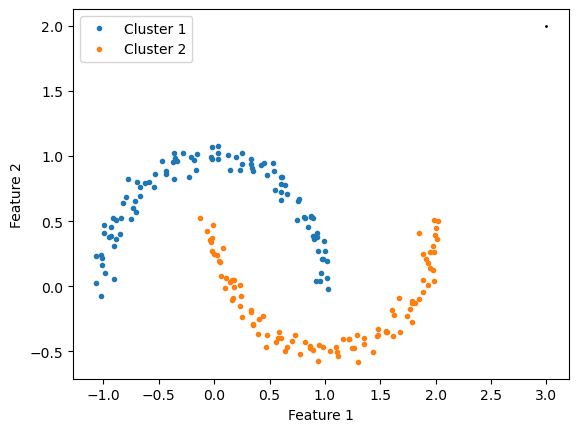

In [8]:
# add a noise point to the dataset
X_moon_with_noise = np.vstack([X_moon, np.array([[3, 2]])])

# rerun the classification
classification_db_with_noise = db.fit_predict(X_moon_with_noise)

# recreate the plot
plt.plot(X_moon_with_noise[:,0], X_moon_with_noise[:,1], 'k.', markersize=2)
for k in range(2):
    plt.plot(X_moon_with_noise[classification_db_with_noise==k,0],
             X_moon_with_noise[classification_db_with_noise==k,1],'.',
             color=colors[k], label='Cluster '+str(k+1))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

As we can see, the point we added is not in either of the clusters. Let's check the classification of this point:

In [9]:
# check the classification of the noise point
print(classification_db_with_noise[-1])

-1


In this case, we see that noise points get the classification -1, indicating it does not belong to any of the clusters.

## OPTICS

OPTICS, short for Ordering Points To Identify the Clustering Structure, is another density-based algorithm for clustering points. The idea of this algorithm is to address cases where clusters may have different densities - an assumption that DBSCAN does not do well with.

Let's take a look at an example where we have clusters of different densities. We can create three clusters using the `make_blobs` function from the previous notebook:

In [10]:
# a data set with two compact clusters with different densities
X1, y_1 = make_blobs(n_samples=200, centers=[(-5, 0)], cluster_std=0.1, random_state=1)
X2, y_2 = make_blobs(n_samples=200, centers=[(-1, 0)],  cluster_std=0.2, random_state=2)
X3, y_3 = make_blobs(n_samples=200, centers=[(5, 0)],  cluster_std=0.8, random_state=3)
X_noise, y_noise = make_blobs(n_samples=200, centers=[(0, 0)],  cluster_std=3, random_state=5)
X_dd_raw = np.vstack([X1, X2, X3, X_noise])
X_dd = (X_dd_raw - np.nanmean(X_dd_raw, axis=0)) / np.nanstd(X_dd_raw, axis=0)

Let's see what this data looks like:

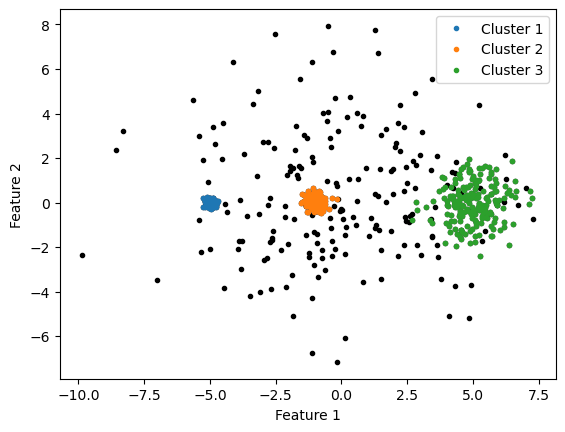

In [11]:
plt.plot(X_dd_raw[:, 0], X_dd_raw[:, 1], 'k.')
plt.plot(X1[:,0],X1[:,1],'.', color=colors[0], label='Cluster '+str(1))
plt.plot(X2[:,0],X2[:,1],'.', color=colors[1], label='Cluster '+str(2))
plt.plot(X3[:,0],X3[:,1],'.', color=colors[2], label='Cluster '+str(3))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

Here, we can see that there are three different clusters with decreasing density. Let's see how DBSCAN performs:

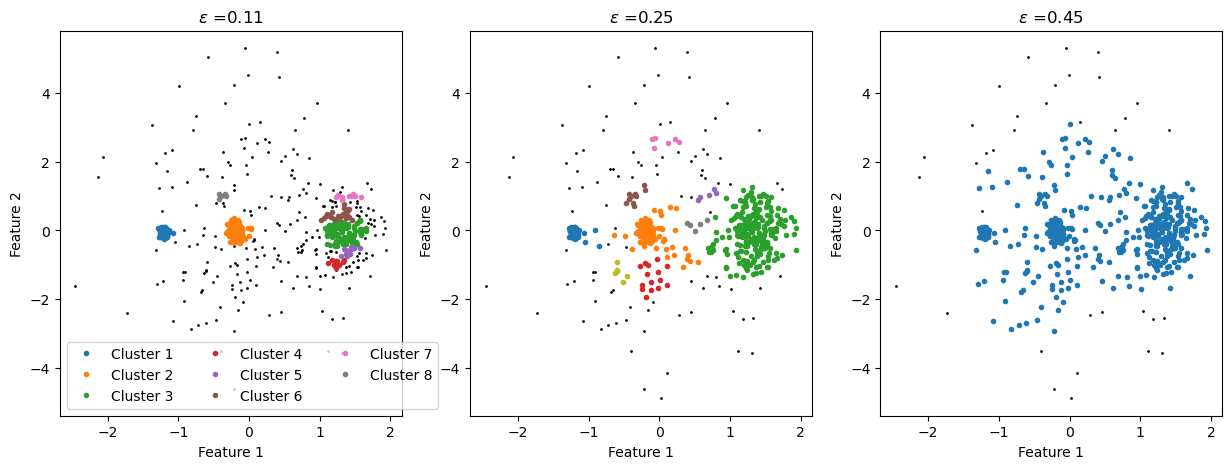

In [12]:
eps1 = 0.11
eps2 = 0.25
eps3 = 0.45

db_small = DBSCAN(eps=eps1).fit(X_dd)
db_medium = DBSCAN(eps=eps2).fit(X_dd)
db_large = DBSCAN(eps=eps3).fit(X_dd)

db_small_classification = db_small.fit_predict(X_dd)
db_medium_classification = db_medium.fit_predict(X_dd)
db_large_classification = db_large.fit_predict(X_dd)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
db_small_unique = np.unique(db_small_classification)
plt.plot(X_dd[:,0], X_dd[:,1],'k.', markersize=2)
for k in db_small_unique:
    if k>=0:
        plt.plot(X_dd[db_small_classification==k,0],
                 X_dd[db_small_classification==k,1],'.',
                 color=colors[k], label='Cluster '+str(k+1))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('$\\varepsilon$ ='+'{:.2f}'.format(eps1))
plt.legend(ncol=3)

plt.subplot(1,3,2)
db_small_medium = np.unique(db_medium_classification)
plt.plot(X_dd[:,0], X_dd[:,1],'k.', markersize=2)
for k in db_small_medium:
    if k>=0:
        plt.plot(X_dd[db_medium_classification==k,0],
                 X_dd[db_medium_classification==k,1],'.',
                 color=colors[k], label='Cluster '+str(k+1))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('$\\varepsilon$ ='+'{:.2f}'.format(eps2))

plt.subplot(1,3,3)
db_small_large = np.unique(db_large_classification)
plt.plot(X_dd[:,0], X_dd[:,1],'k.', markersize=2)
for k in db_small_large:
    if k>=0:
        plt.plot(X_dd[db_large_classification==k,0],
                 X_dd[db_large_classification==k,1],'.',
                 color=colors[k], label='Cluster '+str(k+1))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('$\\varepsilon$ ='+'{:.2f}'.format(eps3))
plt.show()

DBSCAN doesn't do so well on this task because it prescribed a certain density: since each core point is defined by a radius $\varepsilon$ and a number of points within that radius ($m$), this constraint determine how dense an area needs to be.

The OPTICS algorithm attempts to loosen this restriction by defining a "reachability distance" - a point that has at least $m$ values within this distance is considered part of a cluster. The reachability distance is computed as follows:
1. the radius ($\varepsilon$) constraint is relaxed to a large number i.e. clusters by default can be large and quite sparse
2. each point is assigned a "core distance" which is the distance to the $m$th closest point
3. for any two points, the reachability distance is computed as the maximum of the core distance and the distance between the points

It should be noted that the core distance and the reachability distance are both undefined when there are less than $m$ points within $\varepsilon$, and therefore not in a cluster (similar to DBSCAN). 

Let's see an example:

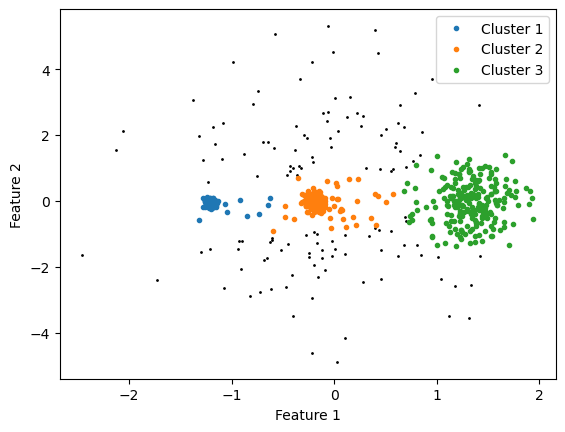

In [13]:
op = OPTICS(min_samples=30,  
            xi=0.05,
            cluster_method="xi")
classification_op = op.fit_predict(X_dd)

# plot the classifications
op_unique = np.unique(classification_op)
plt.plot(X_dd[:,0], X_dd[:,1],'k.', markersize=2)
for k in op_unique:
    if k>=0:
        plt.plot(X_dd[classification_op==k,0],
                 X_dd[classification_op==k,1],'.',
                 color=colors[k], label='Cluster '+str(k+1))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

Here, we can see that the OPTICS clustering algorithm does a fair job identifying the three unique clusters. This is done by examining the ordered reachability distances. Let's gather those and plot those here:

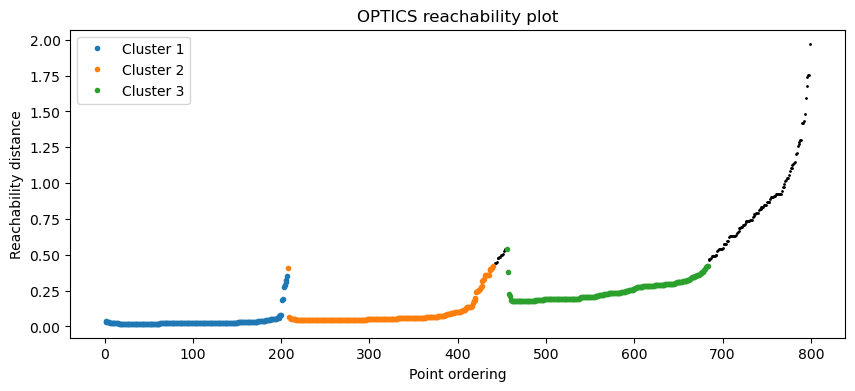

In [14]:
# gather the reachability distances and labels
space = np.arange(len(X_dd))
reachability = op.reachability_[op.ordering_]
classification_op_ordered = classification_op[op.ordering_]

plt.figure(figsize=(10, 4))
plt.plot(space, reachability, "k.", markersize=2)
for k in op_unique:
    if k>=0:
        plt.plot(space[classification_op_ordered==k],
                 reachability[classification_op_ordered==k],'.',
                 color=colors[k], label='Cluster '+str(k+1))
plt.title("OPTICS reachability plot")
plt.xlabel("Point ordering")
plt.ylabel("Reachability distance")
plt.legend()
plt.show()

We can see here how the decisions between clusters are made. The algorithm starts from a given point and searches for the next point with the smallest relative reachability distance. Points close to each other have smaller reachability distances. At some point in the search, the algorithm will run out of close points (measured by the reachability distance), and will need to move to another cluster of points with the next smallest reachability distance (i.e. tightly clustered points). The separation between the clusters can be identified by the peaks in the ordered reachability distance curve.

**Key Takeaways**

1. Density-based clustering offers an alternative to $k$-means clustering where the number of clusters is prescribed.
3. DBSCAN searches for clusters of approximately equal density as defined by a radius and a given number of points.
4. OPTICS improves upon the DBSCAN algorithm by allowing clusters to be formed with different densities.